In [309]:
# Importing necessaries libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import warnings
warnings.filterwarnings('ignore')

# preprocessing libraries
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, StratifiedGroupKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder


# statistical libraries
from scipy import stats
from scipy.stats import zscore, skew

# set style for better visualisations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")


Libraries imported successfully!


In [310]:
data= 'cleaned_loan_dataset.csv'

In [311]:
df= pd.read_csv(data)

In [312]:
numerical_col=df.select_dtypes(include=[np.number]).columns
numerical_col

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

In [313]:
# create a copy for preprocessing 
data= df.copy()

numerical= data[numerical_col]

# 1. checking for missing values (EDA showed no missing values)
print("\n1.  Missing Values:")
missing_values = data.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found (as expected from EDA)")

#2. check for duplicates
print("\n2. Duplicate Rows:")
duplicates = data.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f'Percentage of duplicates: {(duplicates/len(data))* 100:.2sf}%')


# 3. Check skewness for variables identified in EDA as right-skewed
print("\n3. Skewness Analysis (EDA identified right-skewed variables):")    
skewed_vars = ['debt_to_income_ratio','loan_amount','interest_rate', 'credit_score','annual_income']
for var in skewed_vars:
    if var in data.columns:
        skewness = data[var].skew()
        print(f"{var}: skewness = {skewness:.3f} ({'right-skewed' if skewness > 0.5 else 'approximately normal'})")







1.  Missing Values:
No missing values found (as expected from EDA)

2. Duplicate Rows:
Number of duplicate rows: 0

3. Skewness Analysis (EDA identified right-skewed variables):
debt_to_income_ratio: skewness = 1.407 (right-skewed)
loan_amount: skewness = 0.207 (approximately normal)
interest_rate: skewness = 0.050 (approximately normal)
credit_score: skewness = -0.167 (approximately normal)
annual_income: skewness = 1.720 (right-skewed)


## Log-transform skewed variables as recommended by EDA

In [314]:
# Log-transform skewed variables as recommended by EDA
print("=== LOG-TRANSFORMING SKEWED VARIABLES ===")
print("EDA identified these variables as right-skewed and recommended log transformation:")

# Variables to log-transform based on EDA findings
skewed_vars = ['debt_to_income_ratio','loan_amount','interest_rate', 'credit_score','annual_income']

for var in skewed_vars:
    if var in data.columns:
        # Check if variable has zero or negative values
        min_val = data[var].min()
        if min_val <= 0:
            # Use log1p for variables with zeros
            data[f'{var}_log'] = np.log1p(data[var])
            print(f"✓ {var}: Applied log1p transformation (had {min_val:.3f} minimum value)")
        else:
            # Use log for positive values only
            data[f'{var}_log'] = np.log1p(data[var])
            print(f"✓ {var}: Applied log transformation")
        
        # Check skewness before and after
        original_skew = skew(data[var])
        transformed_skew = skew(data[f'{var}_log'])
        print(f"  Original skewness: {original_skew:.3f} → Transformed skewness: {transformed_skew:.3f}")

print(f"\nDataset shape after log transformation: {data.shape}")
print("New log-transformed columns:", [col for col in data.columns if '_log' in col])

=== LOG-TRANSFORMING SKEWED VARIABLES ===
EDA identified these variables as right-skewed and recommended log transformation:
✓ debt_to_income_ratio: Applied log transformation
  Original skewness: 1.407 → Transformed skewness: 1.219
✓ loan_amount: Applied log transformation
  Original skewness: 0.207 → Transformed skewness: -1.694
✓ interest_rate: Applied log transformation
  Original skewness: 0.050 → Transformed skewness: -0.452
✓ credit_score: Applied log transformation
  Original skewness: -0.167 → Transformed skewness: -0.427
✓ annual_income: Applied log transformation
  Original skewness: 1.720 → Transformed skewness: -0.342

Dataset shape after log transformation: (593994, 17)
New log-transformed columns: ['debt_to_income_ratio_log', 'loan_amount_log', 'interest_rate_log', 'credit_score_log', 'annual_income_log']


## Checking out for outliers found in EDA

In [315]:
numerical_col =df.select_dtypes(include=[np.number]).columns
numerical_col
for col in numerical_col:
    print(f'{col} = {df[col].skew():.3f}"  skewness value')




annual_income = 1.720"  skewness value
debt_to_income_ratio = 1.407"  skewness value
credit_score = -0.167"  skewness value
loan_amount = 0.207"  skewness value
interest_rate = 0.050"  skewness value
loan_paid_back = -1.491"  skewness value


In [316]:

# Outlier treatment based on EDA recommendations
print("=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===")

# Define numerical columns (excluding target)
numerical_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'Loan_Status' in numerical_cols:
    numerical_cols.remove('Loan_Status')

print(f"Treating outliers in {len(numerical_cols)} numerical features...")

# Apply IQR-capping method
outliers_capped = 0
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers before capping
    outliers_before = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    
    if outliers_before > 0:
        # Cap outliers
        data[col] = np.where(data[col] < lower_bound, lower_bound, data[col])
        data[col] = np.where(data[col] > upper_bound, upper_bound, data[col])
        outliers_capped += outliers_before
        print(f"✓ {col}: Capped {outliers_before} outliers")

print(f"\nTotal outliers capped: {outliers_capped}")
print(f"Dataset shape after outlier treatment: {data.shape}")

=== OUTLIER TREATMENT (IQR-CAPPING METHOD) ===
Treating outliers in 11 numerical features...
✓ annual_income: Capped 15917 outliers
✓ debt_to_income_ratio: Capped 17556 outliers
✓ credit_score: Capped 5901 outliers
✓ loan_amount: Capped 2902 outliers
✓ interest_rate: Capped 5136 outliers
✓ loan_paid_back: Capped 119500 outliers
✓ debt_to_income_ratio_log: Capped 13412 outliers
✓ loan_amount_log: Capped 37392 outliers
✓ interest_rate_log: Capped 8014 outliers
✓ credit_score_log: Capped 7462 outliers
✓ annual_income_log: Capped 2979 outliers

Total outliers capped: 236171
Dataset shape after outlier treatment: (593994, 17)


## Feature Engineering

In [317]:
data.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,debt_to_income_ratio_log,loan_amount_log,interest_rate_log,credit_score_log,annual_income_log
0,29367.99,0.084,736.0,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.080658,8.327875,2.685805,6.602588,10.287695
1,22108.02,0.166,636.0,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,1.0,0.153579,8.432528,2.633327,6.456770,10.003741
2,49566.20,0.097,694.0,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.092579,9.741330,2.375836,6.543912,10.811085
3,46858.25,0.065,536.5,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.062975,8.451797,2.839078,6.311989,10.754904
4,25496.70,0.053,665.0,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.051643,9.407996,2.416806,6.501290,10.146344


In [318]:
categorical_col= df.select_dtypes(include="object").columns
categorical_col

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

## Scaled numeric data

In [319]:
numerical_col

Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
       'interest_rate', 'loan_paid_back'],
      dtype='object')

In [320]:
# let normalise numeric values to help algorithms like Logistic or SVM perform better.


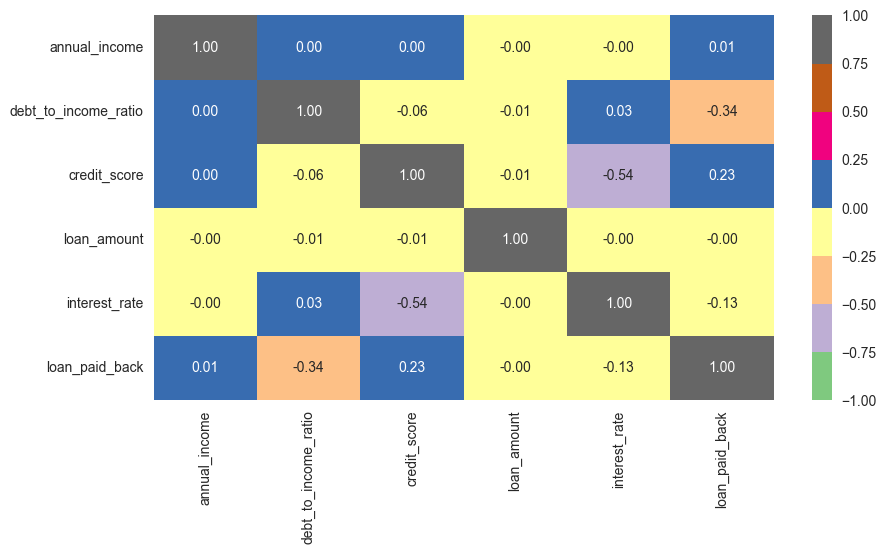

In [321]:
# 3. Examine the correlation of each feature with the target variable (quality)

cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Accent"
)
plt.show()

In [322]:
[numerical_col]

[Index(['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount',
        'interest_rate', 'loan_paid_back'],
       dtype='object')]

# Feature Encoding

In [323]:
from sklearn.calibration import LabelEncoder
# marital_status= ['married']


In [324]:
for col in categorical_col:
    data[col].value_counts()
    print(data[col].value_counts())
    print("="*30)
    print()


gender
Female    306175
Male      284091
Other       3728
Name: count, dtype: int64

marital_status
Single      288843
Married     277239
Divorced     21312
Widowed       6600
Name: count, dtype: int64

education_level
Bachelor's     279606
High School    183592
Master's        93097
Other           26677
PhD             11022
Name: count, dtype: int64

employment_status
Employed         450645
Unemployed        62485
Self-employed     52480
Retired           16453
Student           11931
Name: count, dtype: int64

loan_purpose
Debt consolidation    324695
Other                  63874
Car                    58108
Home                   44118
Education              36641
Business               35303
Medical                22806
Vacation                8449
Name: count, dtype: int64

grade_subgrade
C3    58695
C4    55957
C2    54443
C1    53363
C5    53317
D1    37029
D3    36694
D4    35097
D2    34432
D5    32101
B2    15167
B1    14344
B5    13937
B3    13926
B4    13877
E4     8036


In [325]:


education_order= [['Other',"High School","Bachelor's","Master's",'PhD']]


order= OrdinalEncoder(categories=education_order)
data['education_level']=order.fit_transform(data[['education_level']])



In [326]:
marital_status= [['Married', 'Single', 'Divorced', 'Widowed']]

ohe= OneHotEncoder(categories=marital_status, drop='first', sparse_output=False, handle_unknown='ignore')
encoded_data=ohe.fit_transform(data[["marital_status"]])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=ohe.get_feature_names_out(['marital_status'])
)

encoded_df.index = data.index
data = pd.concat([data.drop(columns=['marital_status']), encoded_df], axis=1)

In [327]:
# employment_status= [['Employed' ,'Unemployed','Self-employed ','Retired ', 'Student']]

# le= LabelEncoder()
#     encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# data["marital_status"]=le.fit_transform(data[["marital_status"]])



In [328]:
# =[['Debt consolidation''Car','Home','Education','Business ','Medical ', 'Vacation','Other']]        

In [334]:
categorical_col
data.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,debt_to_income_ratio_log,loan_amount_log,interest_rate_log,credit_score_log,annual_income_log,marital_status_Single,marital_status_Divorced,marital_status_Widowed
0,29367.99,0.084,736.0,2528.42,13.67,Female,1.0,Self-employed,Other,C3,1.0,0.080658,8.327875,2.685805,6.602588,10.287695,1.0,0.0,0.0
1,22108.02,0.166,636.0,4593.10,12.92,Male,3.0,Employed,Debt consolidation,D3,1.0,0.153579,8.432528,2.633327,6.456770,10.003741,0.0,0.0,0.0
2,49566.20,0.097,694.0,17005.15,9.76,Male,1.0,Employed,Debt consolidation,C5,1.0,0.092579,9.741330,2.375836,6.543912,10.811085,1.0,0.0,0.0
3,46858.25,0.065,536.5,4682.48,16.10,Female,1.0,Employed,Debt consolidation,F1,1.0,0.062975,8.451797,2.839078,6.311989,10.754904,1.0,0.0,0.0
4,25496.70,0.053,665.0,12184.43,10.21,Male,1.0,Employed,Other,D1,1.0,0.051643,9.407996,2.416806,6.501290,10.146344,0.0,0.0,0.0


In [330]:
data.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,debt_to_income_ratio_log,loan_amount_log,interest_rate_log,credit_score_log,annual_income_log,marital_status_Single,marital_status_Divorced,marital_status_Widowed
0,29367.99,0.084,736.0,2528.42,13.67,Female,1.0,Self-employed,Other,C3,1.0,0.080658,8.327875,2.685805,6.602588,10.287695,1.0,0.0,0.0
1,22108.02,0.166,636.0,4593.10,12.92,Male,3.0,Employed,Debt consolidation,D3,1.0,0.153579,8.432528,2.633327,6.456770,10.003741,0.0,0.0,0.0
2,49566.20,0.097,694.0,17005.15,9.76,Male,1.0,Employed,Debt consolidation,C5,1.0,0.092579,9.741330,2.375836,6.543912,10.811085,1.0,0.0,0.0
3,46858.25,0.065,536.5,4682.48,16.10,Female,1.0,Employed,Debt consolidation,F1,1.0,0.062975,8.451797,2.839078,6.311989,10.754904,1.0,0.0,0.0
4,25496.70,0.053,665.0,12184.43,10.21,Male,1.0,Employed,Other,D1,1.0,0.051643,9.407996,2.416806,6.501290,10.146344,0.0,0.0,0.0


In [331]:


categorical_col= df.select_dtypes(include="object").columns

In [332]:
categorical_col

Index(['gender', 'marital_status', 'education_level', 'employment_status',
       'loan_purpose', 'grade_subgrade'],
      dtype='object')

In [333]:
from sklearn.model_selection import train_test_split

# Define X and Y
X = data.drop(columns=["loan_paid_back"])
y = data["loan_paid_back"]

scaler = StandardScaler()
numerical_col = numerical_col.drop('loan_paid_back', errors='ignore')

X[numerical_col]= scaler.fit_transform(x[numerical_col])

# Split into train/test (if not already split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)





NameError: name 'x' is not defined

In [ ]:
print("shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

shape of Training set :  (415795, 16)
Shape of test set :  (178199, 16)
Percentage of classes in training set:
loan_paid_back
1.0    1.0
Name: proportion, dtype: float64
Percentage of classes in test set:
loan_paid_back
1.0    1.0
Name: proportion, dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predict
y_pred = log_reg.predict(X_test)

# Evaluate
print("=== Logistic Regression Baseline ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("\n Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred))


ValueError: could not convert string to float: 'Married'

In [ ]:
plt.figure(figsize=(8, 4))
sns.heatmap(confusion_matrix -Baseline)